In [ ]:
import os

import sys

import json

import pickle

from pathlib import Path

from datetime import datetime

from importlib import reload



current_dir = Path.cwd()

notebook_dir = current_dir / 'main/04_sampling_approximation'

if not (current_dir / '../../utils').resolve().exists() and notebook_dir.exists():

    current_dir = notebook_dir

os.chdir(current_dir)



utilities_dir = (current_dir / '../../utils').resolve()

if str(utilities_dir) not in sys.path:

    sys.path.insert(0, str(utilities_dir))



import plotting

import pinns_infinite

import infinite

reload(plotting)

reload(pinns_infinite)

reload(infinite)



import numpy as np

import torch

from pinns_infinite import train_dual_network, build_models_KAN, set_seed

from plotting import plot_histories_comparison



torch.set_default_dtype(torch.float32)

set_seed(42)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [7]:
OPTIMIZED_CONFIG = {

    'model_type': 'KAN',

    'hidden_layers': 3,

    'hidden_units': 25,

    'grid_size': 5,

    'spline_order': 4,

    'adam_lr': 1e-2,

    'adam_iters': 2000,

    'lbfgs_iters': 2000,

    'sampling': 'gaussian',

    'sigma': 5.5,

    'exp_scale': 1.0,

    'n_obs_u': 100,

    'n_obs_k': 100,

    'n_pde': 1000,

    'seed': 2,

    'pde_alpha': 0.5,

    'pde_beta': 5.0,

    'epsilon': 1.0,

    'adaptive_alpha': 1,

    'update_every': 250,

    'regularization': False,

}



BASELINE_RESULTS_ROOT = Path('results/optimized_kan_infinite_adaptive_comparison')

ADAPTIVE_RESULTS_ROOT = Path('results/optimized_kan_infinite_adaptive_alpha1_update250')

FIGURE_PATH = Path('results/adaptive_vs_fixed_schedules_optimized_kan_infinite_alpha1_update250.pdf')

FORCE_RETRAIN_CASES = set()



TRAINING_CASES = [

    {

        'name': 'fixed_nosched_no_reg',

        'title': 'Fixed',

        'lambda_pde_scheduler': False,

        'adaptive_weights': False,

        'results_root': BASELINE_RESULTS_ROOT,

    },

    {

        'name': 'fixed_sched_no_reg',

        'title': r'$\lambda_{\mathrm{PDE}}$ schedule',

        'lambda_pde_scheduler': True,

        'adaptive_weights': False,

        'results_root': BASELINE_RESULTS_ROOT,

    },

    {

        'name': 'adaptive_sched_no_reg',

        'title': r'$\lambda_{\mathrm{PDE}}$ schedule + adaptive',

        'lambda_pde_scheduler': True,

        'adaptive_weights': True,

        'results_root': ADAPTIVE_RESULTS_ROOT,

    },

]





def serializable_case(case):

    return {

        key: str(value) if isinstance(value, Path) else value

        for key, value in case.items()

    }





def run_or_load_history(case):

    run_dir = case['results_root'] / case['name']

    history_path = run_dir / 'history.pkl'

    config_path = run_dir / 'config.json'



    if history_path.exists() and case['name'] not in FORCE_RETRAIN_CASES:

        with open(history_path, 'rb') as f:

            return pickle.load(f)



    run_dir.mkdir(parents=True, exist_ok=True)

    set_seed(OPTIMIZED_CONFIG['seed'])



    model_u, model_k = build_models_KAN(

        device=device,

        hidden_layers=OPTIMIZED_CONFIG['hidden_layers'],

        hidden_units=OPTIMIZED_CONFIG['hidden_units'],

        grid_size=OPTIMIZED_CONFIG['grid_size'],

        spline_order=OPTIMIZED_CONFIG['spline_order'],

    )



    history = train_dual_network(

        model_u=model_u,

        model_k=model_k,

        adam_lr=OPTIMIZED_CONFIG['adam_lr'],

        adam_iters=OPTIMIZED_CONFIG['adam_iters'],

        lbfgs_iters=OPTIMIZED_CONFIG['lbfgs_iters'],

        verbose=True,

        print_every=100,

        save_every=100,

        lambda_pde_scheduler=case['lambda_pde_scheduler'],

        adaptive_weights=case['adaptive_weights'],

        alpha=OPTIMIZED_CONFIG['adaptive_alpha'],

        update_every=OPTIMIZED_CONFIG['update_every'],

        regularization=OPTIMIZED_CONFIG['regularization'],

        sampling=OPTIMIZED_CONFIG['sampling'],

        sigma=OPTIMIZED_CONFIG['sigma'],

        exp_scale=OPTIMIZED_CONFIG['exp_scale'],

        n_obs_u=OPTIMIZED_CONFIG['n_obs_u'],

        n_obs_k=OPTIMIZED_CONFIG['n_obs_k'],

        n_pde=OPTIMIZED_CONFIG['n_pde'],

        seed=OPTIMIZED_CONFIG['seed'],

        save_results=False,

        pde_alpha=OPTIMIZED_CONFIG['pde_alpha'],

        pde_beta=OPTIMIZED_CONFIG['pde_beta'],

        epsilon=OPTIMIZED_CONFIG['epsilon'],

        device=device,

    )



    history['optimized_config'] = OPTIMIZED_CONFIG.copy()

    history['training_case'] = serializable_case(case)



    with open(history_path, 'wb') as f:

        pickle.dump(history, f)

    with open(config_path, 'w') as f:

        json.dump(

            {

                'optimized_config': OPTIMIZED_CONFIG,

                'training_case': serializable_case(case),

                'created_at': datetime.now().isoformat(timespec='seconds'),

            },

            f,

            indent=2,

        )

    torch.save(model_u.state_dict(), run_dir / 'model_u.pt')

    torch.save(model_k.state_dict(), run_dir / 'model_k.pt')



    return history



Training with Adam
Adam     0 | Total=7.696e+00 | ObsU=1.354e-02 | ObsK=5.302e+00 | PDE=2.380e+01 | Ratio=391.73 | ErrU=1.843e+00 | ErrK=9.396e-01
Adam   100 | Total=4.331e-01 | ObsU=8.603e-03 | ObsK=6.655e-03 | PDE=4.179e+00 | Ratio=391.73 | ErrU=8.440e-01 | ErrK=3.578e-02
Adam   200 | Total=4.892e-03 | ObsU=2.034e-04 | ObsK=1.327e-03 | PDE=3.361e-02 | Ratio=239.81 | ErrU=1.194e-01 | ErrK=1.612e-02
V      = [0.007 1.77 ]
R      = [0. 1.]
ratio  = 237.69
lambda_u = 1.000
lambda_k = 25.769
lambda_pde = 0.100
Adam   300 | Total=3.601e-02 | ObsU=5.605e-04 | ObsK=6.419e-04 | PDE=1.891e-01 | Ratio=237.69 | ErrU=1.856e-01 | ErrK=1.117e-02
Adam   400 | Total=8.114e-03 | ObsU=1.808e-04 | ObsK=7.036e-05 | PDE=2.448e-02 | Ratio=231.90 | ErrU=1.215e-01 | ErrK=3.716e-03
V      = [0.005 1.062]
R      = [0. 1.]
ratio  = 230.08
lambda_u = 1.000
lambda_k = 25.008
lambda_pde = 0.250
Adam   500 | Total=2.607e-03 | ObsU=1.268e-04 | ObsK=3.020e-05 | PDE=6.809e-03 | Ratio=230.08 | ErrU=9.628e-02 | ErrK=2.

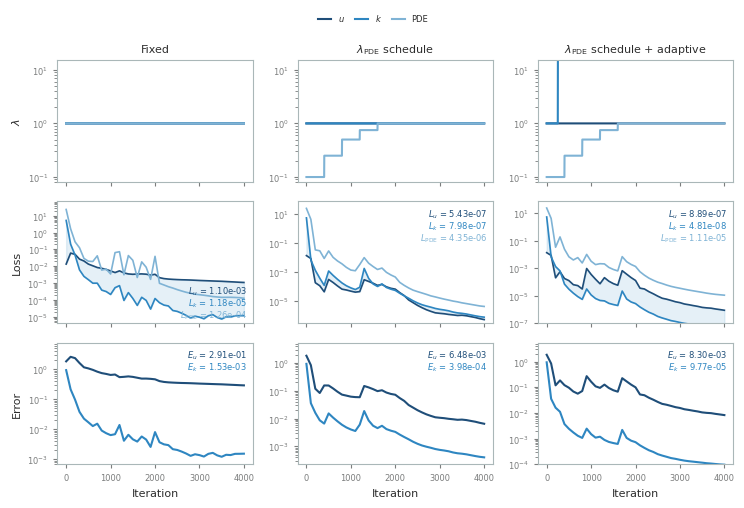

Saved optimized comparison figure to results/adaptive_vs_fixed_schedules_optimized_kan_infinite_alpha1_update250.pdf


In [8]:
histories = [run_or_load_history(case) for case in TRAINING_CASES]

plot_histories_comparison(
    histories,
    titles=[case['title'] for case in TRAINING_CASES],
    save_path=str(FIGURE_PATH),
)

print(f'Saved optimized comparison figure to {FIGURE_PATH}')

In [12]:
import numpy as np



ADAPTIVE_SWEEP_CONFIGS = [

    {'adaptive_alpha': 0.05, 'update_every': 250, 'name': 'adaptive_alpha0.05_update250'},

    {'adaptive_alpha': 0.10, 'update_every': 250, 'name': 'adaptive_alpha0.10_update250'},

    {'adaptive_alpha': 0.15, 'update_every': 250, 'name': 'adaptive_alpha0.15_update250'},

    {'adaptive_alpha': 0.20, 'update_every': 250, 'name': 'adaptive_alpha0.20_update250'},

    {'adaptive_alpha': 0.25, 'update_every': 250, 'name': 'adaptive_alpha0.25_update250'},

]



SWEEP_RESULTS_ROOT = Path('results/optimized_kan_infinite_adaptive_sweep')

PRECOMPUTED_ADAPTIVE_RUNS = {

    'adaptive_alpha1_update250': Path('results/optimized_kan_infinite_adaptive_alpha1_update250/adaptive_sched_no_reg'),

}





def final_finite_value(values):

    finite_values = [value for value in values if value is not None and np.isfinite(value)]

    return finite_values[-1] if finite_values else np.nan





def run_adaptive_sweep_case(sweep_config):

    run_dir = SWEEP_RESULTS_ROOT / sweep_config['name']

    history_path = run_dir / 'history.pkl'

    config_path = run_dir / 'config.json'



    if history_path.exists():

        with open(history_path, 'rb') as f:

            return pickle.load(f)



    precomputed_run_dir = PRECOMPUTED_ADAPTIVE_RUNS.get(sweep_config['name'])

    precomputed_history_path = None if precomputed_run_dir is None else precomputed_run_dir / 'history.pkl'

    if precomputed_history_path is not None and precomputed_history_path.exists():

        with open(precomputed_history_path, 'rb') as f:

            return pickle.load(f)



    run_dir.mkdir(parents=True, exist_ok=True)

    set_seed(OPTIMIZED_CONFIG['seed'])



    model_u, model_k = build_models_KAN(

        device=device,

        hidden_layers=OPTIMIZED_CONFIG['hidden_layers'],

        hidden_units=OPTIMIZED_CONFIG['hidden_units'],

        grid_size=OPTIMIZED_CONFIG['grid_size'],

        spline_order=OPTIMIZED_CONFIG['spline_order'],

    )



    history = train_dual_network(

        model_u=model_u,

        model_k=model_k,

        adam_lr=OPTIMIZED_CONFIG['adam_lr'],

        adam_iters=OPTIMIZED_CONFIG['adam_iters'],

        lbfgs_iters=OPTIMIZED_CONFIG['lbfgs_iters'],

        verbose=True,

        print_every=100,

        save_every=100,

        lambda_pde_scheduler=True,

        adaptive_weights=True,

        alpha=sweep_config['adaptive_alpha'],

        update_every=sweep_config['update_every'],

        regularization=OPTIMIZED_CONFIG['regularization'],

        sampling=OPTIMIZED_CONFIG['sampling'],

        sigma=OPTIMIZED_CONFIG['sigma'],

        exp_scale=OPTIMIZED_CONFIG['exp_scale'],

        n_obs_u=OPTIMIZED_CONFIG['n_obs_u'],

        n_obs_k=OPTIMIZED_CONFIG['n_obs_k'],

        n_pde=OPTIMIZED_CONFIG['n_pde'],

        seed=OPTIMIZED_CONFIG['seed'],

        save_results=False,

        pde_alpha=OPTIMIZED_CONFIG['pde_alpha'],

        pde_beta=OPTIMIZED_CONFIG['pde_beta'],

        epsilon=OPTIMIZED_CONFIG['epsilon'],

        device=device,

    )



    history['optimized_config'] = OPTIMIZED_CONFIG.copy()

    history['adaptive_sweep_config'] = sweep_config.copy()



    with open(history_path, 'wb') as f:

        pickle.dump(history, f)

    with open(config_path, 'w') as f:

        json.dump(

            {

                'optimized_config': OPTIMIZED_CONFIG,

                'adaptive_sweep_config': sweep_config,

                'created_at': datetime.now().isoformat(timespec='seconds'),

            },

            f,

            indent=2,

        )

    torch.save(model_u.state_dict(), run_dir / 'model_u.pt')

    torch.save(model_k.state_dict(), run_dir / 'model_k.pt')



    return history





adaptive_sweep_rows = []

adaptive_sweep_histories = {}



for sweep_config in ADAPTIVE_SWEEP_CONFIGS:

    history = run_adaptive_sweep_case(sweep_config)

    error_u = final_finite_value(history.get('error_u', []))

    error_k = final_finite_value(history.get('error_k', []))

    lambda_k = final_finite_value(history.get('lambda_k', []))

    adaptive_sweep_histories[sweep_config['name']] = history

    adaptive_sweep_rows.append(

        {

            'name': sweep_config['name'],

            'adaptive_alpha': sweep_config['adaptive_alpha'],

            'update_every': sweep_config['update_every'],

            'error_u': error_u,

            'error_k': error_k,

            'mean_error': 0.5 * (error_u + error_k),

            'lambda_k_final': lambda_k,

        }

    )



adaptive_sweep_summary = sorted(adaptive_sweep_rows, key=lambda row: row['mean_error'])

adaptive_sweep_summary



Training with Adam
Adam     0 | Total=7.696e+00 | ObsU=1.354e-02 | ObsK=5.302e+00 | PDE=2.380e+01 | Ratio=391.73 | ErrU=1.843e+00 | ErrK=9.396e-01
Adam   100 | Total=4.331e-01 | ObsU=8.603e-03 | ObsK=6.655e-03 | PDE=4.179e+00 | Ratio=391.73 | ErrU=8.440e-01 | ErrK=3.578e-02
Adam   200 | Total=4.892e-03 | ObsU=2.034e-04 | ObsK=1.327e-03 | PDE=3.361e-02 | Ratio=239.81 | ErrU=1.194e-01 | ErrK=1.612e-02
V      = [0.007 1.77 ]
R      = [0. 1.]
ratio  = 237.69
lambda_u = 1.000
lambda_k = 2.238
lambda_pde = 0.100
Adam   300 | Total=1.945e-03 | ObsU=1.014e-04 | ObsK=1.860e-04 | PDE=1.427e-02 | Ratio=237.69 | ErrU=8.650e-02 | ErrK=5.838e-03
Adam   400 | Total=1.966e-03 | ObsU=5.171e-05 | ObsK=5.807e-05 | PDE=7.139e-03 | Ratio=236.62 | ErrU=7.623e-02 | ErrK=4.670e-03
V      = [0.004 1.062]
R      = [0. 1.]
ratio  = 236.08
lambda_u = 1.000
lambda_k = 2.230
lambda_pde = 0.250
Adam   500 | Total=6.774e-03 | ObsU=2.511e-04 | ObsK=3.380e-04 | PDE=2.306e-02 | Ratio=236.08 | ErrU=1.407e-01 | ErrK=8.11

[{'name': 'adaptive_alpha0.05_update250',
  'adaptive_alpha': 0.05,
  'update_every': 250,
  'error_u': 0.0069604068994522095,
  'error_k': 0.0002915274817496538,
  'mean_error': 0.0036259671906009316,
  'lambda_k_final': np.float64(2.1486681459528736)},
 {'name': 'adaptive_alpha0.15_update250',
  'adaptive_alpha': 0.15,
  'update_every': 250,
  'error_u': 0.007615508511662483,
  'error_k': 0.0001691875804681331,
  'mean_error': 0.003892348046065308,
  'lambda_k_final': np.float64(4.204088412354925)},
 {'name': 'adaptive_alpha0.25_update250',
  'adaptive_alpha': 0.25,
  'update_every': 250,
  'error_u': 0.008128723129630089,
  'error_k': 0.00015544357302132994,
  'mean_error': 0.004142083351325709,
  'lambda_k_final': np.float64(6.901220590721421)},
 {'name': 'adaptive_alpha0.20_update250',
  'adaptive_alpha': 0.2,
  'update_every': 250,
  'error_u': 0.00903676263988018,
  'error_k': 0.0001639841211726889,
  'mean_error': 0.004600373380526435,
  'lambda_k_final': np.float64(5.295608028